In [1]:
import requests
import pandas as pd
import json

# 1. API 설정
api_key = "본인의 api-key 입력"
url = "http://apis.data.go.kr/B552584/ArpltnInforInqireSvc/getCtprvnRltmMesureDnsty"

params = {
    "serviceKey": api_key,
    "returnType": "json",
    "numOfRows": "100",   # 가져올 데이터 수
    "pageNo": "1",
    "sidoName": "서울",     # 조회할 지역
    "ver": "1.0"
}

# 2. API 호출 및 JSON 파싱
response = requests.get(url, params=params)
data = json.loads(response.text)

# 3. DataFrame으로 변환
items = data['response']['body']['items']
df = pd.DataFrame(items)

print(df.head())

  so2Grade coFlag khaiValue so2Value coValue pm25Flag pm10Flag o3Grade  \
0        1   None        77    0.002     0.4     None     None       2   
1        1   None        56    0.002     0.4     None     None       2   
2     None   통신장애         -        -       -     통신장애     통신장애    None   
3        1   None        74    0.002     0.5     None     None       1   
4        1   None        72    0.002     0.4     None     None       2   

  pm10Value khaiGrade  ... no2Grade o3Flag pm25Grade so2Flag  \
0        41         2  ...        1   None         2    None   
1        39         2  ...        1   None         2    None   
2         -      None  ...     None   통신장애      None    통신장애   
3        45         2  ...        1   None         2    None   
4        43         2  ...        1   None         2    None   

           dataTime coGrade no2Value stationName pm10Grade o3Value  
0  2026-03-06 10:00       1    0.016          중구         2   0.036  
1  2026-03-06 10:00       1    0

In [6]:
df.shape

(39, 8)

In [2]:
df.head()

,so2Grade,coFlag,khaiValue,so2Value,coValue,pm25Flag,pm10Flag,o3Grade,pm10Value,khaiGrade,...,no2Grade,o3Flag,pm25Grade,so2Flag,dataTime,coGrade,no2Value,stationName,pm10Grade,o3Value
0,1,None,77,0.002,0.4,None,None,2,41,2,...,1,None,2,None,2026-03-06 10:00,1,0.016,중구,2,0.036
1,1,None,56,0.002,0.4,None,None,2,39,2,...,1,None,2,None,2026-03-06 10:00,1,0.022,한강대로,2,0.032
2,None,통신장애,-,-,-,통신장애,통신장애,None,-,None,...,None,통신장애,None,통신장애,2026-03-06 10:00,None,-,종로구,None,-
3,1,None,74,0.002,0.5,None,None,1,45,2,...,1,None,2,None,2026-03-06 10:00,1,0.020,청계천로,2,0.030
4,1,None,72,0.002,0.4,None,None,2,43,2,...,1,None,2,None,2026-03-06 10:00,1,0.011,종로,2,0.040


In [3]:
import numpy as np

# 1. 필요한 컬럼만 추출 (측정일시, 측정소명, 미세먼지, 초미세먼지)
df = df[['dataTime', 'stationName', 'pm10Value', 'pm25Value']]

# 2. 데이터 타입 변환 (문자열 -> 숫자형 및 날짜형)
# API에서 통신 오류 등으로 '-' 문자가 들어오는 경우가 있어 NaN으로 변환 후 float 처리
# raise	오류 발생 (기본값) , ignore	변환 안 하고 그대로 둠 , coerce	NaN으로 변환
df['pm10Value'] = pd.to_numeric(df['pm10Value'], errors='coerce')
df['pm25Value'] = pd.to_numeric(df['pm25Value'], errors='coerce')
df['dataTime'] = pd.to_datetime(df['dataTime'])

# 3. 결측치 처리 (여기서는 단순 제거를 사용)
df = df.dropna()

# 4. 특성 공학 (Feature Engineering)
# 4-1. 시간대, 요일, 월 파생 변수 생성
df['hour'] = df['dataTime'].dt.hour
df['day_of_week'] = df['dataTime'].dt.day_name()
df['month'] = df['dataTime'].dt.month

# 4-2. 미세먼지(PM10) 등급화 (한국 환경부 기준)
# 0~30: 좋음, 31~80: 보통, 81~150: 나쁨, 151~: 매우나쁨
conditions = [
    (df['pm10Value'] <= 30),
    (df['pm10Value'] > 30) & (df['pm10Value'] <= 80),
    (df['pm10Value'] > 80) & (df['pm10Value'] <= 150),
    (df['pm10Value'] > 150)
]
choices = ['좋음', '보통', '나쁨', '매우나쁨']
df['pm10_grade'] = np.select(conditions, choices, default='알수없음')

print(df[['stationName', 'dataTime', 'pm10Value', 'hour', 'pm10_grade']].head())

  stationName            dataTime  pm10Value  hour pm10_grade
0          중구 2026-03-06 10:00:00       41.0    10         보통
1        한강대로 2026-03-06 10:00:00       39.0    10         보통
3        청계천로 2026-03-06 10:00:00       45.0    10         보통
4          종로 2026-03-06 10:00:00       43.0    10         보통
5         용산구 2026-03-06 10:00:00       48.0    10         보통


In [4]:
df.head()

,dataTime,stationName,pm10Value,pm25Value,hour,day_of_week,month,pm10_grade
0,2026-03-06 10:00:00,중구,41.0,30.0,10,Friday,3,보통
1,2026-03-06 10:00:00,한강대로,39.0,29.0,10,Friday,3,보통
3,2026-03-06 10:00:00,청계천로,45.0,29.0,10,Friday,3,보통
4,2026-03-06 10:00:00,종로,43.0,30.0,10,Friday,3,보통
5,2026-03-06 10:00:00,용산구,48.0,32.0,10,Friday,3,보통


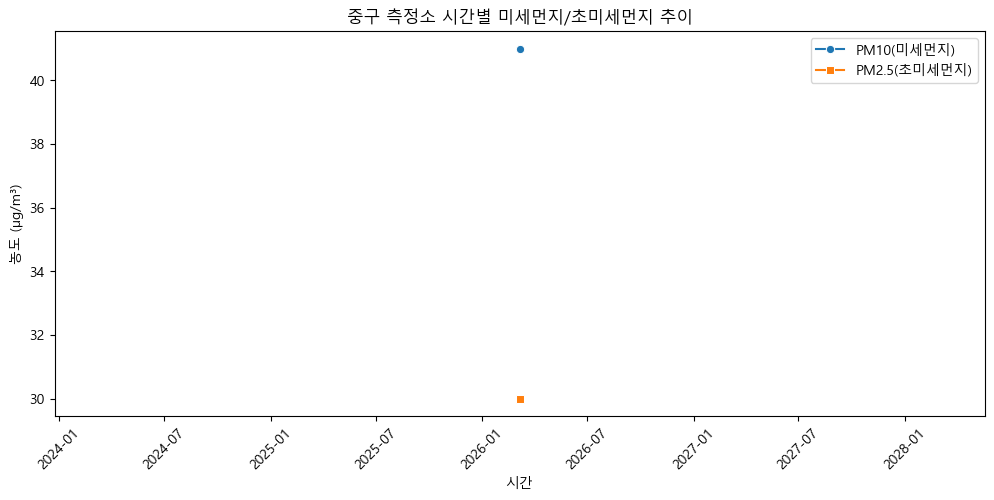

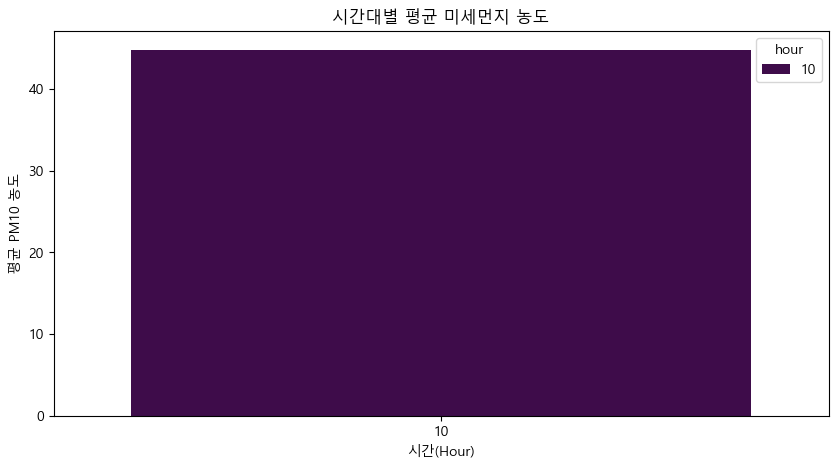

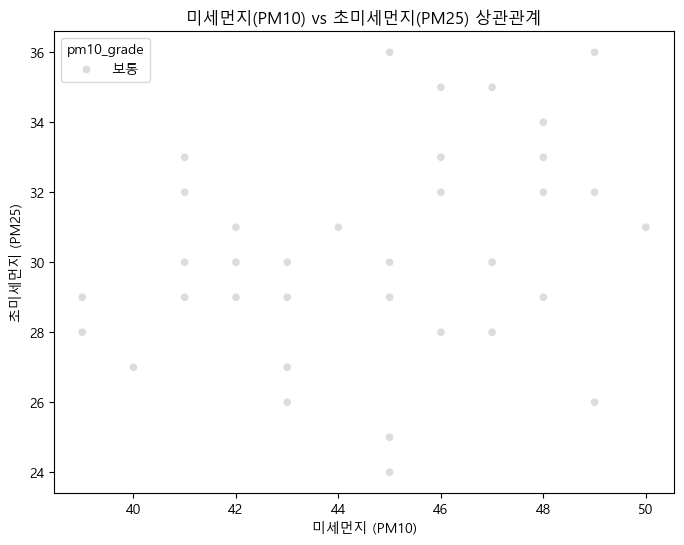

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 시각화 1: 특정 측정소의 시간별 미세먼지 추이 (Line Plot)
target_station = df['stationName'].iloc[0] # 첫 번째 측정소 기준
df_station = df[df['stationName'] == target_station]

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_station, x='dataTime', y='pm10Value', label='PM10(미세먼지)', marker='o')
sns.lineplot(data=df_station, x='dataTime', y='pm25Value', label='PM2.5(초미세먼지)', marker='s')
plt.title(f'{target_station} 측정소 시간별 미세먼지/초미세먼지 추이')
plt.xlabel('시간')
plt.ylabel('농도 (µg/m³)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# 시각화 2: 서울시 전체 시간대별 평균 미세먼지 농도 (Bar Plot)
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='hour', y='pm10Value', hue='hour',errorbar=None, palette='viridis')
plt.title('시간대별 평균 미세먼지 농도')
plt.xlabel('시간(Hour)')
plt.ylabel('평균 PM10 농도')
plt.show()

# 시각화 3: 미세먼지와 초미세먼지의 상관관계 (Scatter Plot)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='pm10Value', y='pm25Value', hue='pm10_grade', palette='coolwarm')
plt.title('미세먼지(PM10) vs 초미세먼지(PM25) 상관관계')
plt.xlabel('미세먼지 (PM10)')
plt.ylabel('초미세먼지 (PM25)')
plt.show()